# Classification


## MNIST Dataset:

In [3]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()
X, y = mnist["data"], mnist["target"]
X.shape

(70000, 784)

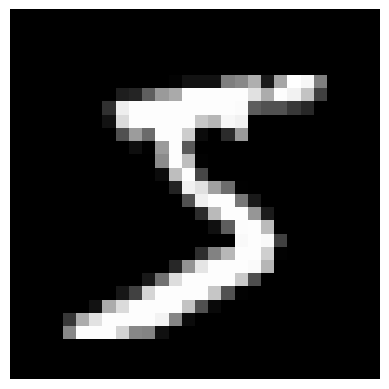

Etiqueta (y[0]): 5

Pixel matrix (28x28) - formatted:
00:   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
01:   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
02:   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
03:   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
04:   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
05:   0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0
06:   0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0
07:   0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0
08:   0   0   0   

In [4]:
import matplotlib.pyplot as plt
import numpy as np

some_digit = X.iloc[0].to_numpy()
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap="gray")
plt.axis("off")
plt.show()

print("Etiqueta (y[0]):", y.iloc[0])
print("\nPixel matrix (28x28) - formatted:")
pixel_matrix = some_digit_image.astype(np.uint8)
for row_idx, row in enumerate(pixel_matrix):
    row_values = " ".join(f"{value:3d}" for value in row)
    print(f"{row_idx:02d}: {row_values}")

print("\nTipo:", some_digit_image.dtype)
print("Min pixel:", some_digit_image.min(), "| Max pixel:", some_digit_image.max())

## Cutting the dataset into training and testing sets

In [5]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:70000], y[:60000], y[60000:70000]

## Binary classification: Is the digit 5 or not?

In [ ]:
y_train_5 = (y_train == "5")
y_test_5 = (y_test == "5")

## Training the model

In [9]:
import numpy as np

print("y_train dtype:", y_train.dtype)
print("classes y_train:", np.unique(y_train)[:10], " ... total:", len(np.unique(y_train)))

# Se y_train for string, compare com "5"; se for numérico, compare com 5
y_train_5 = (y_train == "5") if y_train.dtype.kind in {"U", "S", "O"} else (y_train == 5)

print("classes y_train_5:", np.unique(y_train_5), "counts:", np.bincount(y_train_5.astype(int)))

y_train dtype: category
classes y_train: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']  ... total: 10
classes y_train_5: [False  True] counts: [54579  5421]


## Classification Cross Validation

In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
skfolds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train.iloc[train_index]
    y_train_folds = y_train_5.iloc[train_index]
    X_test_fold = X_train.iloc[test_index]
    y_test_fold = y_train_5.iloc[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = (y_pred == y_test_fold).sum()
    print(f"Fold accuracy: {n_correct}/{len(y_pred)} = {n_correct / len(y_pred):.2%}")

Fold accuracy: 18084/20000 = 90.42%
Fold accuracy: 18954/20000 = 94.77%
Fold accuracy: 19357/20000 = 96.78%


## Seeing the accuracy

In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

## The Confusion Matrix
# Confusion Matrix & Metrics (Quick Guide)

A confusion matrix compares predicted labels with true labels in a binary classifier.

## Confusion Matrix

|                | Predicted Positive | Predicted Negative |
|----------------|-------------------|-------------------|
| **Actual Positive** | TP (True Positive) | FN (False Negative) |
| **Actual Negative** | FP (False Positive) | TN (True Negative) |

Let $N = TP + TN + FP + FN$ be the total number of samples.

---

## Key Metrics

### Accuracy
Overall proportion of correct predictions:

$$
\mathrm{Accuracy} = \frac{TP + TN}{N} = \frac{TP + TN}{TP + TN + FP + FN}
$$

### Precision (Positive Predictive Value)
Among predicted positives, how many are truly positive:

$$
\mathrm{Precision} = \frac{TP}{TP + FP}
$$

Focus: false positives.

### Recall (Sensitivity, True Positive Rate)
Among actual positives, how many are correctly found:

$$
\mathrm{Recall} = \frac{TP}{TP + FN}
$$

Focus: false negatives.

### F1-Score
Harmonic mean of Precision and Recall:

$$
F_1 = 2\,\frac{\mathrm{Precision}\cdot\mathrm{Recall}}{\mathrm{Precision}+\mathrm{Recall}}
$$

Equivalent form:

$$
F_1 = \frac{2TP}{2TP + FP + FN}
$$

---

## Extra Useful Metrics

Specificity (True Negative Rate):

$$
\mathrm{Specificity} = \frac{TN}{TN + FP}
$$

False Positive Rate:

$$
\mathrm{FPR} = \frac{FP}{FP + TN} = 1 - \mathrm{Specificity}
$$

False Negative Rate:

$$
\mathrm{FNR} = \frac{FN}{FN + TP} = 1 - \mathrm{Recall}
$$

---

## When To Use What?

- **Accuracy**: best when classes are balanced and errors have similar cost.
- **Precision**: best when false positives are expensive.
- **Recall**: best when missing positives is expensive.
- **F1-score**: best when you need a balance between Precision and Recall.